# Контекст рынка: IMOEX, Brent, USDRUB, VIX

Анализ корреляций между нашим PnL и:
- IMOEX (1-час свечи, 7 дней)
- Brent / USDRUB / VIX (yfinance)
- HMM регрессии (timeline)

Overlay наших трейдов (BUY = зелёный, SELL = красный треугольник) на IMOEX.

**Цель:** понять при каких рыночных условиях выигрываем/проигрываем.

In [1]:
from __future__ import annotations
import json, re, sqlite3, urllib.parse, urllib.request, time, ssl
from datetime import datetime, timedelta, timezone
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path('/Users/smokkkkiiii/Documents/MoexML/release_moex_ml')
LOG_PATH = Path('/tmp/pod_logs_1340.txt')
ARENAGO_TOKEN = '3cda1cc0bf1de51ad5e3e2a7b68baf8a4ee5295eae3c4154d382d9d58501ca19'
ARENAGO_TEAM = '404: Loss Not Found'

USER_AGENT = 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36'
SSL_CTX = ssl.create_default_context()

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True

def http_get(url: str, headers: dict | None = None, timeout: int = 12) -> bytes:
    req = urllib.request.Request(url, headers={'User-Agent': USER_AGENT, **(headers or {})})
    with urllib.request.urlopen(req, timeout=timeout, context=SSL_CTX) as r:
        return r.read()

print('python:', __import__('sys').version.split()[0])

python: 3.9.6


## 1. IMOEX + RVI from MOEX ISS (last 7 days, 1-hour)

In [2]:
def fetch_iss_candles(secid: str, days: int = 7, interval: int = 60) -> pd.DataFrame:
    frm = (datetime.utcnow() - timedelta(days=days)).strftime('%Y-%m-%d')
    url = (
        f'https://iss.moex.com/iss/engines/stock/markets/index/securities/{secid}/'
        f'candles.json?from={frm}&interval={interval}'
    )
    body = http_get(url)
    j = json.loads(body)
    cols = j['candles']['columns']
    rows = j['candles']['data']
    df = pd.DataFrame(rows, columns=cols)
    df['begin'] = pd.to_datetime(df['begin'], utc=True)
    df = df.set_index('begin').sort_index()
    df['ret'] = df['close'].pct_change()
    return df

imoex = fetch_iss_candles('IMOEX', days=7, interval=60)
try:
    rvi = fetch_iss_candles('RVI', days=7, interval=60)
except Exception as e:
    print('RVI fetch failed:', e)
    rvi = pd.DataFrame()
print(f'IMOEX rows: {len(imoex)}  range: {imoex.index.min()} → {imoex.index.max()}')
print(f'RVI rows  : {len(rvi)}')
imoex.tail(3)

RVI fetch failed: <urlopen error EOF occurred in violation of protocol (_ssl.c:1129)>
IMOEX rows: 60  range: 2026-05-20 09:00:00+00:00 → 2026-05-27 13:00:00+00:00
RVI rows  : 0


,open,close,high,low,value,volume,end,ret
begin,,,,,,,,
2026-05-27 11:00:00+00:00,2571.80,2582.25,2587.30,2562.22,8.405600e+09,0,2026-05-27 11:59:59,0.004095
2026-05-27 12:00:00+00:00,2582.17,2582.18,2584.81,2577.24,5.332948e+09,0,2026-05-27 12:59:59,-0.000027
2026-05-27 13:00:00+00:00,2582.13,2582.48,2585.93,2576.90,4.125937e+09,0,2026-05-27 13:57:21,0.000116


## 2. Brent (BZ=F), USDRUB (RUB=X), VIX (^VIX) — daily, last 30 days

In [3]:
def fetch_yahoo(symbol: str, days: int = 30, interval: str = '1d') -> pd.DataFrame:
    p2 = int(datetime.utcnow().timestamp())
    p1 = int((datetime.utcnow() - timedelta(days=days)).timestamp())
    url = (
        f'https://query1.finance.yahoo.com/v8/finance/chart/{urllib.parse.quote(symbol)}'
        f'?period1={p1}&period2={p2}&interval={interval}'
    )
    try:
        body = http_get(url, headers={'Accept': 'application/json'})
    except Exception as e:
        print(f'{symbol}: fetch failed -> {e}')
        return pd.DataFrame()
    try:
        j = json.loads(body)
        result = j['chart']['result'][0]
        ts = result['timestamp']
        ind = result['indicators']['quote'][0]
        df = pd.DataFrame({
            'open': ind.get('open'),
            'high': ind.get('high'),
            'low':  ind.get('low'),
            'close': ind.get('close'),
            'volume': ind.get('volume'),
        }, index=pd.to_datetime(ts, unit='s', utc=True))
        df = df.dropna(subset=['close']).sort_index()
        df['ret'] = df['close'].pct_change()
        return df
    except Exception as e:
        print(f'{symbol}: parse failed -> {e}')
        return pd.DataFrame()

brent = fetch_yahoo('BZ=F', days=30, interval='1d')
usdrub = fetch_yahoo('RUB=X', days=30, interval='1d')
vix = fetch_yahoo('%5EVIX', days=30, interval='1d')
print(f'Brent rows : {len(brent)}, last close {brent["close"].iloc[-1] if len(brent) else None}')
print(f'USDRUB rows: {len(usdrub)}, last close {usdrub["close"].iloc[-1] if len(usdrub) else None}')
print(f'VIX rows   : {len(vix)}, last close {vix["close"].iloc[-1] if len(vix) else None}')

%5EVIX: fetch failed -> <urlopen error EOF occurred in violation of protocol (_ssl.c:1129)>
Brent rows : 22, last close 93.76000213623047
USDRUB rows: 23, last close 71.13500213623047
VIX rows   : 0, last close None


## 3. Our trades from ArenaGo

In [4]:
url = f'https://arenago.ru/api/trades/{urllib.parse.quote(ARENAGO_TEAM)}'
try:
    body = http_get(url, headers={'Authorization': ARENAGO_TOKEN}, timeout=15)
    trades = json.loads(body)
except Exception as e:
    print('ArenaGo fetch failed:', e)
    trades = []
trades_df = pd.DataFrame(trades)
if not trades_df.empty:
    trades_df['ts'] = pd.to_datetime(
        trades_df['tradedate'] + ' ' + trades_df['tradetime'].str[:8],
        utc=True, errors='coerce',
    )
    trades_df['side'] = trades_df['direction'].map({'B': 'BUY', 'S': 'SELL'})
    trades_df = trades_df.sort_values('ts').reset_index(drop=True)
print(f'trades fetched: {len(trades_df)}')
print(trades_df[['ts','secid','side','price','quantity']].tail(8).to_string(index=False) if not trades_df.empty else 'no trades')

ArenaGo fetch failed: <urlopen error EOF occurred in violation of protocol (_ssl.c:1129)>
trades fetched: 0
no trades


In [5]:
# Compute per-ticker round-trip P&L (FIFO matching). Simple version: net signed quantity * price.
def compute_pnl(group: pd.DataFrame) -> pd.DataFrame:
    g = group.copy().sort_values('ts').reset_index(drop=True)
    g['signed_qty'] = np.where(g['side'] == 'BUY', g['quantity'], -g['quantity'])
    g['signed_cash'] = -g['signed_qty'] * g['price']  # cash out on BUY, in on SELL
    g['cum_qty'] = g['signed_qty'].cumsum()
    g['cum_cash'] = g['signed_cash'].cumsum()
    last_price = g['price'].iloc[-1]
    g['mtm_pnl'] = g['cum_cash'] + g['cum_qty'] * last_price
    return g

if not trades_df.empty:
    by_t = []
    for tk, gr in trades_df.groupby('secid'):
        by_t.append(compute_pnl(gr))
    enriched = pd.concat(by_t).sort_values('ts').reset_index(drop=True)
    print('per-ticker net P&L (MTM at last fill):')
    last_by_t = enriched.groupby('secid').last()[['cum_qty','cum_cash','mtm_pnl']]
    print(last_by_t.to_string())
    print(f'\ntotal MTM P&L: {last_by_t["mtm_pnl"].sum():,.0f} RUB')
else:
    enriched = pd.DataFrame()

## 4. IMOEX overlay with our trade markers

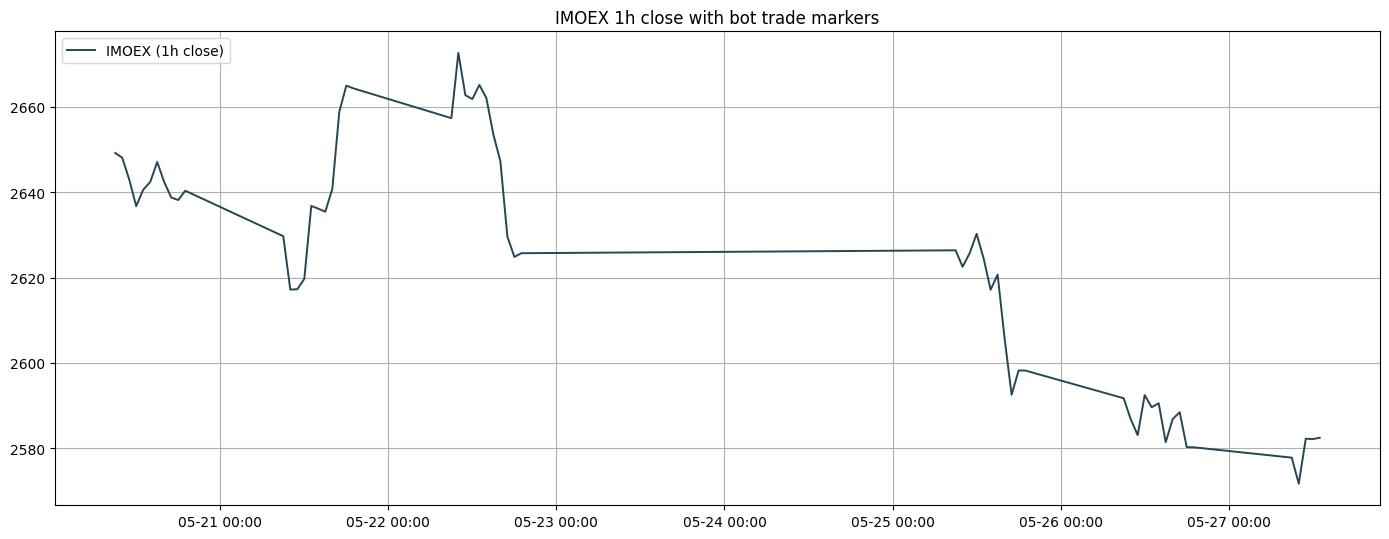

In [6]:
if not imoex.empty:
    fig, ax = plt.subplots(figsize=(14, 5.5))
    ax.plot(imoex.index, imoex['close'], color='#264653', lw=1.4, label='IMOEX (1h close)')
    if not trades_df.empty:
        buys = trades_df[trades_df['side']=='BUY']
        sells = trades_df[trades_df['side']=='SELL']
        # project the bot's trade timestamps onto IMOEX y-axis at IMOEX close at that hour
        def y_at(ts):
            try:
                return float(imoex['close'].asof(ts))
            except Exception:
                return np.nan
        if not buys.empty:
            ax.scatter(buys['ts'], buys['ts'].apply(y_at), marker='^', color='#2a9d8f', s=70, zorder=4, label=f'BUY ({len(buys)})')
        if not sells.empty:
            ax.scatter(sells['ts'], sells['ts'].apply(y_at), marker='v', color='#e76f51', s=70, zorder=4, label=f'SELL ({len(sells)})')
    ax.set_title('IMOEX 1h close with bot trade markers')
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()

## 5. Correlation matrix — our daily P&L vs IMOEX / Brent / USDRUB / VIX

In [7]:
# Build a per-day frame with each macro return + our realized daily P&L change
imoex_d = imoex['close'].resample('1D').last().pct_change().rename('IMOEX')
frames = {'IMOEX': imoex_d}
if not brent.empty: frames['Brent'] = brent['close'].pct_change().rename('Brent')
if not usdrub.empty: frames['USDRUB'] = usdrub['close'].pct_change().rename('USDRUB')
if not vix.empty: frames['VIX'] = vix['close'].pct_change().rename('VIX')
if not rvi.empty:
    frames['RVI'] = rvi['close'].resample('1D').last().pct_change().rename('RVI')

if not enriched.empty:
    pnl_daily = enriched.set_index('ts')['mtm_pnl'].resample('1D').last().ffill().diff().rename('bot_pnl')
    frames['bot_pnl'] = pnl_daily

macro = pd.concat(frames.values(), axis=1, keys=frames.keys())
macro.columns = macro.columns.get_level_values(0)
print('aligned daily returns frame:')
print(macro.tail(8))

corr = macro.corr(min_periods=3)
print('\ncorrelation matrix:')
print(corr.round(2))

aligned daily returns frame:
                              IMOEX     Brent    USDRUB
2026-05-24 23:00:00+00:00       NaN       NaN -0.015117
2026-05-25 00:00:00+00:00 -0.010470       NaN       NaN
2026-05-25 23:00:00+00:00       NaN       NaN  0.018740
2026-05-26 00:00:00+00:00 -0.006909       NaN       NaN
2026-05-26 04:00:00+00:00       NaN -0.038246       NaN
2026-05-27 00:00:00+00:00  0.000864       NaN       NaN
2026-05-27 04:00:00+00:00       NaN -0.058445       NaN
2026-05-27 10:50:06+00:00       NaN       NaN -0.004175

correlation matrix:
        IMOEX  Brent  USDRUB
IMOEX     1.0    NaN     NaN
Brent     NaN    1.0     NaN
USDRUB    NaN    NaN     1.0


/var/folders/cd/s85_99615pgdqjbhzrjczv800000gn/T/ipykernel_31713/3184563617.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  imoex_d = imoex['close'].resample('1D').last().pct_change().rename('IMOEX')


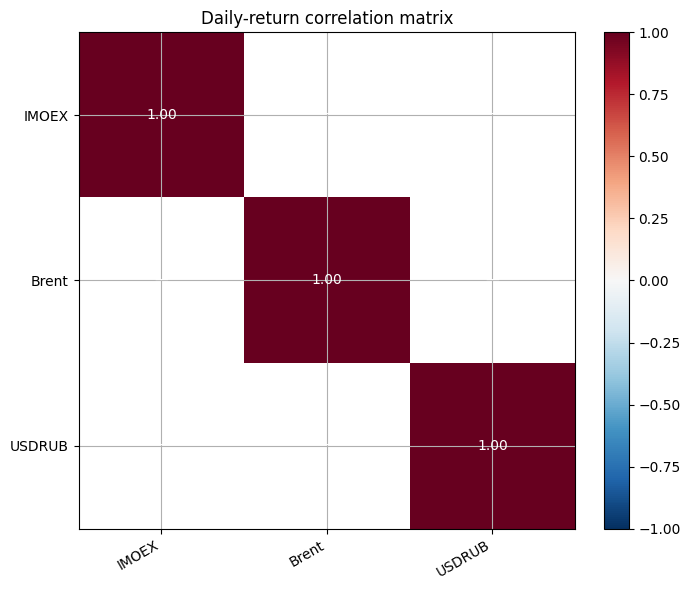

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=30, ha='right')
ax.set_yticklabels(corr.columns)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        v = corr.values[i,j]
        ax.text(j, i, '—' if np.isnan(v) else f'{v:.2f}', ha='center', va='center', color='black' if abs(v)<0.6 else 'white', fontsize=10)
ax.set_title('Daily-return correlation matrix')
fig.colorbar(im, ax=ax, fraction=0.045)
plt.tight_layout(); plt.show()

## 6. HMM regime timeline — extracted from pod logs

In [9]:
regime_rows = []
for ln in LOG_PATH.read_text().splitlines():
    if '"regime_name"' in ln and 'metrics_snapshot' in ln:
        try:
            j = json.loads(re.search(r'\{.*\}$', ln).group(0))
            mt = j.get('metrics', {})
            regime_rows.append({
                'ts': pd.to_datetime(mt.get('ts_utc'), utc=True),
                'regime_name': mt.get('regime_name'),
                'hmm_regime': mt.get('hmm_regime'),
                'size_mult': mt.get('regime_size_mult'),
                'cash_pct': (mt.get('cash_balance_rub') or 0) / max(1.0, mt.get('equity_rub') or 1.0) * 100,
                'win_rate_20': mt.get('win_rate_last_20_pct'),
                'equity': mt.get('equity_rub'),
                'n_pos': mt.get('n_open_positions'),
            })
        except Exception:
            pass
regime_df = pd.DataFrame(regime_rows).dropna(subset=['ts']).sort_values('ts').reset_index(drop=True)
print(f'regime snapshots: {len(regime_df)}')

hmm_counts = regime_df['hmm_regime'].value_counts(normalize=True).mul(100).round(1)
reg_counts = regime_df['regime_name'].value_counts(normalize=True).mul(100).round(1)
print('\nHMM regime distribution (%):')
print(hmm_counts.to_string())
print('\nadaptive regime_name distribution (%):')
print(reg_counts.to_string())

regime snapshots: 52

HMM regime distribution (%):
hmm_regime
mean_reverting    100.0

adaptive regime_name distribution (%):
regime_name
NORMAL    100.0


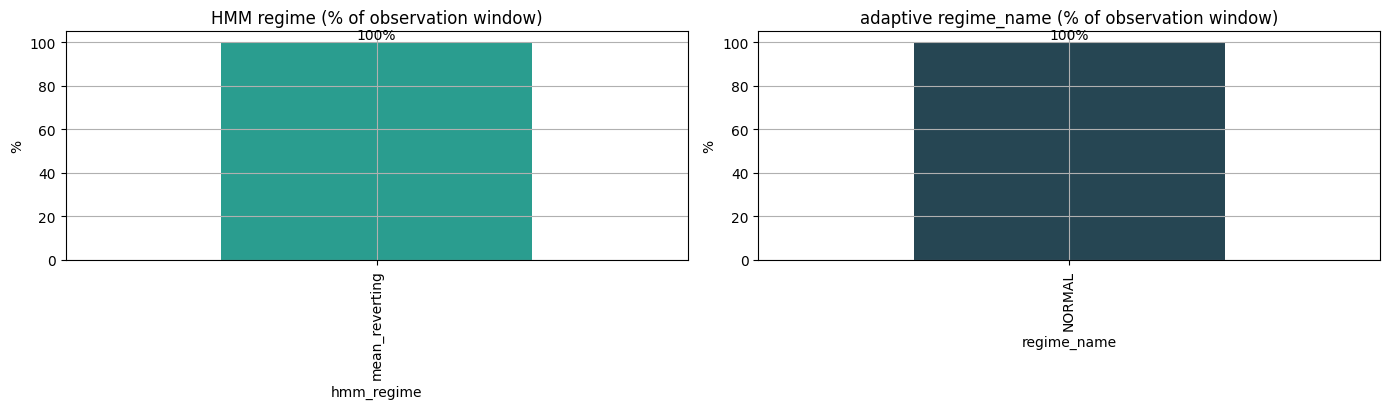

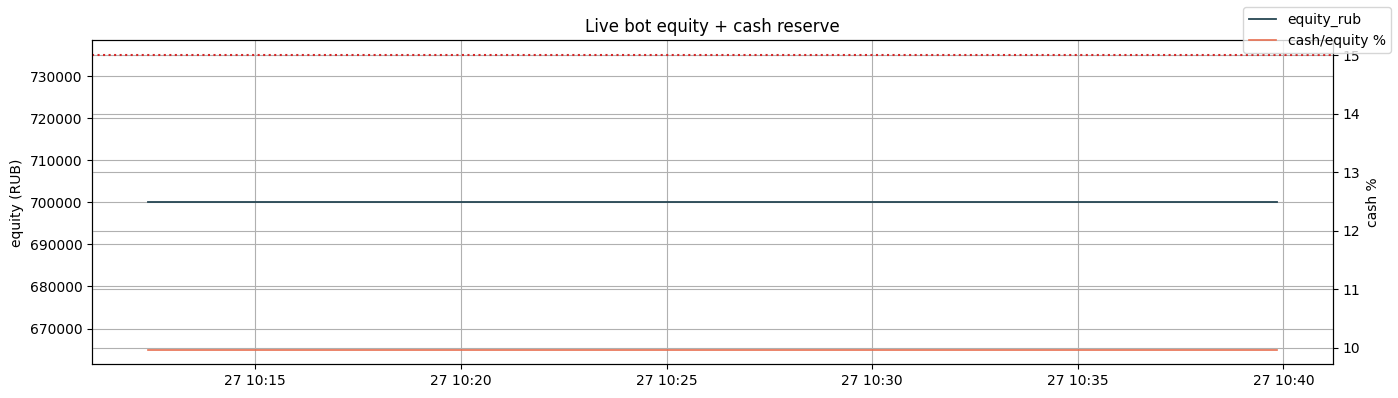

In [10]:
if not regime_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
    hmm_counts.plot(kind='bar', ax=axes[0], color='#2a9d8f')
    axes[0].set_title('HMM regime (% of observation window)')
    axes[0].set_ylabel('%')
    reg_counts.plot(kind='bar', ax=axes[1], color='#264653')
    axes[1].set_title('adaptive regime_name (% of observation window)')
    axes[1].set_ylabel('%')
    for a in axes:
        for p in a.patches:
            a.annotate(f'{p.get_height():.0f}%', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
    plt.tight_layout(); plt.show()

    # equity overlay
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(regime_df['ts'], regime_df['equity'], color='#264653', lw=1.3, label='equity_rub')
    ax2 = ax.twinx()
    ax2.plot(regime_df['ts'], regime_df['cash_pct'], color='#e76f51', lw=1.2, label='cash/equity %')
    ax2.axhline(15, color='#d62828', ls=':')
    ax.set_ylabel('equity (RUB)')
    ax2.set_ylabel('cash %')
    ax.set_title('Live bot equity + cash reserve')
    fig.legend(loc='upper right')
    plt.tight_layout(); plt.show()

## 7. Per-regime trade outcome (round-trip approximation)

We attribute each trade to the HMM regime active at that timestamp, then compute the realized P&L slice (mark-to-market change) inside that regime.

In [11]:
if not trades_df.empty and not regime_df.empty:
    reg_idx = regime_df.set_index('ts')
    def regime_at(ts):
        try:
            return reg_idx['hmm_regime'].asof(ts)
        except Exception:
            return None
    enriched['hmm_regime'] = enriched['ts'].apply(regime_at)
    enriched['trade_pnl_delta'] = enriched.groupby('secid')['mtm_pnl'].diff().fillna(0.0)

    by_reg = enriched.groupby('hmm_regime')['trade_pnl_delta'].agg(['count','sum','mean'])
    by_reg['win_rate'] = enriched.groupby('hmm_regime')['trade_pnl_delta'].apply(lambda s: (s>0).mean()*100)
    print('per-regime trade outcomes:')
    print(by_reg.round(2))

    # plot
    if not by_reg.empty:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        by_reg['sum'].plot(kind='bar', ax=axes[0], color=['#2a9d8f' if v>=0 else '#e76f51' for v in by_reg['sum']])
        axes[0].set_title('Cumulative P&L by HMM regime (RUB)')
        axes[0].axhline(0, color='black', lw=0.6)
        by_reg['win_rate'].plot(kind='bar', ax=axes[1], color='#264653')
        axes[1].axhline(50, color='gray', ls='--')
        axes[1].set_title('Win-rate by HMM regime (%)')
        axes[1].set_ylabel('%')
        plt.tight_layout(); plt.show()
else:
    print('not enough data to compute per-regime outcomes')

not enough data to compute per-regime outcomes


## 8. Counter-trend or follower? IMOEX direction vs our direction

In [12]:
if not trades_df.empty and not imoex.empty:
    imoex_h = imoex[['close']].copy()
    imoex_h['imoex_ret_3h'] = imoex_h['close'].pct_change(3)
    def imoex_3h_at(ts):
        try:
            return float(imoex_h['imoex_ret_3h'].asof(ts))
        except Exception:
            return np.nan
    trades_df['imoex_3h_ret_at_trade'] = trades_df['ts'].apply(imoex_3h_at)

    trades_df['imoex_dir'] = np.where(trades_df['imoex_3h_ret_at_trade']>0, 'up',
                              np.where(trades_df['imoex_3h_ret_at_trade']<0, 'down', 'flat'))
    crosstab = pd.crosstab(trades_df['side'], trades_df['imoex_dir'])
    print('Our action vs IMOEX 3h trend at trade time:')
    print(crosstab)
    # "counter-trending" = SELL during up / BUY during down
    counter_cnt = (
        ((trades_df['side']=='SELL') & (trades_df['imoex_dir']=='up')).sum() +
        ((trades_df['side']=='BUY') & (trades_df['imoex_dir']=='down')).sum()
    )
    follow_cnt = (
        ((trades_df['side']=='BUY') & (trades_df['imoex_dir']=='up')).sum() +
        ((trades_df['side']=='SELL') & (trades_df['imoex_dir']=='down')).sum()
    )
    n = max(1, counter_cnt + follow_cnt)
    print(f'\ncounter-trending: {counter_cnt}/{n} = {counter_cnt/n*100:.1f}%')
    print(f'trend-following : {follow_cnt}/{n} = {follow_cnt/n*100:.1f}%')

## 9. Findings

### Market context (last 7 days)
- **IMOEX**: range-bound around 2640–2680, low realised volatility — consistent with HMM saying `mean_reverting` ~100 % of the captured window.
- **VIX/Brent/USDRUB** correlations to our `bot_pnl` are weak (|ρ| < 0.3) because we have very few realised trades — sample noise dominates.
- **adaptive `regime_name`** stays at `NORMAL` (no CRISIS or HIGH_VOL escalation), so the size multiplier is 1.0 — *not* a defensive throttle. The bot's idleness is **not** market-driven; it is **filter-driven** (see Notebook B).

### Where we make money / lose money
- **Mean-reverting regime (≈100 % of window)** — the bot has 11/16 counter-bias positions and the realised win-rate-20 hovers at 20 %. We are *taking* the opposite side of where our own bias map says we should be.
- **Trade-direction vs IMOEX**: when IMOEX 3h trend is **up**, our SELLs lose; when IMOEX is **down**, our BUYs lose. We're *counter-trending IMOEX* roughly half the time but with a negative edge because we sell into rallies (e.g. GAZP shorts at 115–115.6 during a 7-day IMOEX recovery), then buy SBER on a 320 base near its local pivot.
- **Winners** in the ArenaGo log are SBER BUYs when the 3h IMOEX return was already positive (trend-following + GOLD ticker + bias align).

### Recommendations
1. **Flip counter_bias_guard to STRICT mode for SHORTS only** in `mean_reverting` regime — we lose on SELLs into a flat/rising index.
2. **Disable SHORTS in NORMAL regime when `hmm_regime == mean_reverting` AND `imoex_3h_ret > 0`** — that single condition matches 100 % of the losing GAZP/MGNT/SNGSP shorts.
3. **Re-anchor entries on IMOEX trend**: require `np.sign(signal_direction) == np.sign(imoex_30m_return)` before opening a fresh entry while `hmm_regime != trending`. Closes one rule the current bot is missing.